# Portfolio of Evidence – Part 1
## Lutendo Netshirando ST10105269

In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, length, avg, min, max

##  Spark Initialization

As required by the portfolio requirements, Spark will be used for data processing and exploratory analysis. The dataset can be processed using Spark on the available computer resources thanks to the local Spark session.

In [6]:
spark = (
    SparkSession.builder
    .appName("Part1_LSTM_Author_Classification")
    .master("local[*]")
    .getOrCreate()
)

print("Spark version:", spark.version)

C:\Users\luten\anaconda3\envs\lstm_env\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark version: 4.2.0


## Configuring a Database Connection

A SQLite database contains the dataset. Before choosing the data needed for the analysis, the database will be connected to and its available tables will be examined.

In [7]:
db_path = r"C:\Users\luten\books.db"

conn = sqlite3.connect(db_path)

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,book_original
1,text_files
2,book_file
3,authors
4,books


## Analyzing the Database Structure

The fields needed to connect the literary text to its matching author will be found by looking at each database table's columns.

In [8]:
for table in tables["name"]:
    print(f"\n--- {table} ---")
    
    columns = pd.read_sql_query(
        f"PRAGMA table_info({table});",
        conn
    )
    
    display(columns)


--- book_original ---


,cid,name,type,notnull,dflt_value,pk
0,0,index,BIGINT,0,None,0
1,1,cate1,TEXT,0,None,0
2,2,bookname,TEXT,0,None,0
3,3,chapter,TEXT,0,None,0
4,4,path,TEXT,0,None,0
5,5,pf,TEXT,0,None,0
6,6,author,TEXT,0,None,0
7,7,born,TEXT,0,None,0
8,8,death,TEXT,0,None,0



--- text_files ---


,cid,name,type,notnull,dflt_value,pk
0,0,index,BIGINT,0,None,0
1,1,fmt,TEXT,0,None,0
2,2,text,TEXT,0,None,0



--- book_file ---


,cid,name,type,notnull,dflt_value,pk
0,0,index,BIGINT,0,None,0
1,1,file_id,BIGINT,0,None,0
2,2,book_id,BIGINT,0,None,0
3,3,chapter,TEXT,0,None,0



--- authors ---


,cid,name,type,notnull,dflt_value,pk
0,0,index,BIGINT,0,None,0
1,1,author,TEXT,0,None,0
2,2,born,BIGINT,0,None,0
3,3,death,BIGINT,0,None,0



--- books ---


,cid,name,type,notnull,dflt_value,pk
0,0,book_id,BIGINT,0,None,0
1,1,bookname,TEXT,0,None,0
2,2,author_id,BIGINT,0,None,0
3,3,cate1,TEXT,0,None,0


## Creating the Analysis Dataset

The identifier fields of the relevant tables are used to link them. While the `books` table connects books to authors, the `book_file` table connects text files to books. The text and author label needed for supervised classification are included in the final dataset.

In [10]:
query = """
SELECT
    tf."index" AS text_id,
    b.book_id,
    b.bookname,
    a.author,
    tf.text
FROM text_files AS tf
INNER JOIN book_file AS bf
    ON tf."index" = bf.file_id
INNER JOIN books AS b
    ON bf.book_id = b.book_id
INNER JOIN authors AS a
    ON b.author_id = a."index"
WHERE tf.text IS NOT NULL
  AND TRIM(tf.text) <> ''
"""

df = pd.read_sql_query(query, conn)

print("Number of records:", len(df))
df.head()

Number of records: 10171


,text_id,book_id,bookname,author,text
0,0,943,The Song Of Roland,Nan,\n\n\n\n\n\n\n\nThe Song of Roland\n\n\n\n\n\n...
1,1,54,Aesop's Fables,Aesop,\n\n\n\n\n\n\n\n\n\n\t\tAesop's Fables \n\n\n\...
2,2,681,The Arabian Nights,Nan,\n\n\n\n\n\n\n\n\n\n KHALIFAH THE...
3,3,681,The Arabian Nights,Nan,\n\n\n\n\n\n\n\n\n\n ...
4,4,681,The Arabian Nights,Nan,\n\n\n\n\n\n\n\n\n\n THE FISHE...


##  The Source Tables Are Loaded

The SQLite database has different tables for text files, books, authors, and book-to-file links. Before being merged into the final analysis dataset, these tables will be loaded and examined. This method makes it possible to confirm the linkages between the tables prior to modeling.

In [5]:
authors_df = pd.read_sql_query(
    'SELECT * FROM authors',
    conn
)

books_df = pd.read_sql_query(
    'SELECT * FROM books',
    conn
)

book_file_df = pd.read_sql_query(
    'SELECT * FROM book_file',
    conn
)

text_files_df = pd.read_sql_query(
    'SELECT * FROM text_files',
    conn
)

print("Authors:", len(authors_df))
print("Books:", len(books_df))
print("Book-file links:", len(book_file_df))
print("Text files:", len(text_files_df))

Authors: 292
Books: 1087
Book-file links: 10171
Text files: 10171


## Merging the Source Tables

Identifier fields of the source tables are used to merge them. As a result, the text, book details, and author label needed for the classification task are combined into a single dataset.

In [7]:
df = (
    text_files_df
    .merge(
        book_file_df,
        left_on="index",
        right_on="file_id",
        how="inner"
    )
    .merge(
        books_df,
        on="book_id",
        how="inner"
    )
    .merge(
        authors_df,
        left_on="author_id",
        right_on="index",
        how="inner",
        suffixes=("", "_author")
    )
)

df = df[
    ["index", "book_id", "bookname", "author", "text"]
].rename(
    columns={"index": "text_id"}
)

print("Combined records:", len(df))
print("Columns:", list(df.columns))

Combined records: 10171
Columns: ['text_id', 'book_id', 'bookname', 'author', 'text']


## Exploratory Data Analysis

Before developing a model, the structure and quality of the dataset are evaluated using exploratory data analysis, or EDA. The study focuses on text length, author representation, duplicate records, and missing variables.

In [9]:
csv_path = r"C:\Users\luten\part1_books.csv"

df.to_csv(
    csv_path,
    index=False,
    quoting=1
)

print("CSV recreated with proper text quoting.")
print("Records:", len(df))

CSV recreated with proper text quoting.
Records: 10171


In [10]:
spark_df = (
    spark.read
    .option("header", True)
    .option("quote", '"')
    .option("escape", '"')
    .option("multiLine", True)
    .option("inferSchema", True)
    .csv(csv_path)
)

print("Spark records:", spark_df.count())
spark_df.printSchema()

Spark records: 10171
root
 |-- text_id: integer (nullable = true)
 |-- book_id: integer (nullable = true)
 |-- bookname: string (nullable = true)
 |-- author: string (nullable = true)
 |-- text: string (nullable = true)



## Missing Values

Missing-value analysis is performed to identify incomplete records that could affect the reliability of the classification model. Each variable is checked for null, empty and blank values before further preprocessing.


In [11]:
from pyspark.sql.functions import col, sum as spark_sum, when, trim

missing_values = spark_df.select([
    spark_sum(
        when(
            col(c).isNull() | (trim(col(c).cast("string")) == ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in spark_df.columns
])

missing_values.show()

+-------+-------+--------+------+----+
|text_id|book_id|bookname|author|text|
+-------+-------+--------+------+----+
|      0|      0|       0|     0|   0|
+-------+-------+--------+------+----+



## Duplicate Records

To find repeated observations that can skew the study, duplicate records are looked at. In order to guaranty that the training data comprises separate text samples, duplicate entries are eliminated.

In [12]:
total_records = spark_df.count()
unique_records = spark_df.dropDuplicates().count()
duplicate_records = total_records - unique_records

print("Total records:", total_records)
print("Unique records:", unique_records)
print("Duplicate records:", duplicate_records)

Total records: 10171
Unique records: 10171
Duplicate records: 0


## Author Distribution

To determine whether the target classes are balanced, the distribution of records among writers is analyzed. A classification model may favor authors with more observations due to class imbalance.

In [13]:
author_counts = (
    spark_df
    .groupBy("author")
    .count()
    .orderBy(col("count").desc())
)

author_counts.show(30, truncate=False)

+-----------------------+-----+
|author                 |count|
+-----------------------+-----+
|Charles Dickens        |1063 |
|Mark Twain             |463  |
|Alexandre Dumas        |385  |
|Thomas Hardy           |360  |
|Walter Scott           |353  |
|Leo Tolstoy            |307  |
|Jack London            |293  |
|Elizabeth C. Gaskell   |256  |
|Jane Austen            |247  |
|Wilkie Collins         |246  |
|Henry James            |243  |
|George Eliot           |228  |
|Robert Louis Stevenson |227  |
|Jules Verne            |185  |
|H. G. Wells            |183  |
|Andrew Lang            |171  |
|Sir Arthur Conan Doyle |166  |
|Joseph Conrad          |150  |
|Miguel De Cervantes    |133  |
|Hans C. Andersen       |128  |
|Edith Wharton          |113  |
|George Borrow          |109  |
|Aristotle              |97   |
|Nathaniel Hawthorne    |94   |
|Washington Irving      |93   |
|Frances Hodgson Burnett|88   |
|Herman Melville        |88   |
|Alexander Hamilton     |86   |
|John S.

## Author Distribution

The author distribution shows substantial class imbalance. Charles Dickens has the largest number of records with 1,063 samples, while several authors have fewer than 200 samples. This imbalance may cause the LSTM model to favour authors with more observations.

To reduce this bias, a balanced subset will be created by selecting authors with sufficient observations and limiting each selected class to the same number of text samples.


C:\Users\luten\anaconda3\envs\lstm_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


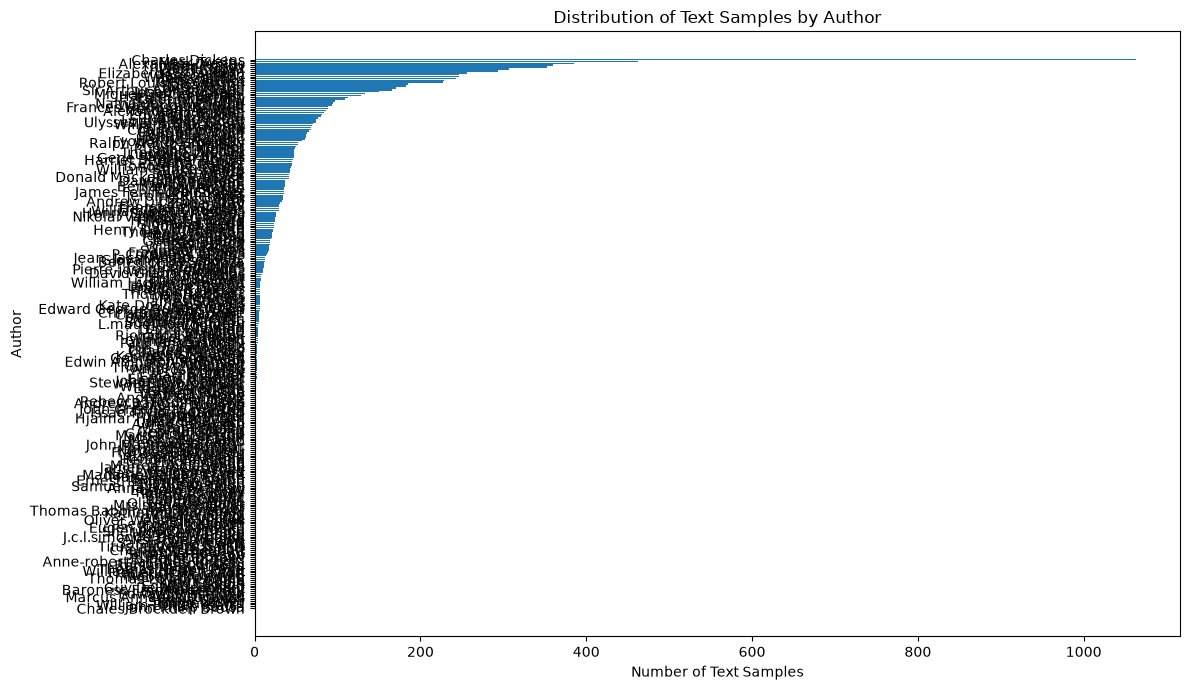

In [15]:
author_pd = author_counts.toPandas()

plt.figure(figsize=(12, 7))
plt.barh(author_pd["author"], author_pd["count"])
plt.xlabel("Number of Text Samples")
plt.ylabel("Author")
plt.title("Distribution of Text Samples by Author")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Text Length Analysis

Text length is examined to identify unusually short or long observations. Large differences in text length may affect sequence preparation and computational requirements for the LSTM model. Descriptive statistics will therefore be used to understand the distribution of text lengths.


## Analysis of Text Length

To find observations that are abnormally short or long, text length is analyzed. Sequence preparation and computing requirements for the LSTM model may be impacted by significant variations in text length. In order to comprehend the distribution of text lengths, descriptive statistics will be employed.

In [17]:
text_length_df = spark_df.withColumn(
    "text_length",
    length(col("text"))
)

text_length_df.select(
    "text_length"
).summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
).show()

+-------+-----------------+
|summary|      text_length|
+-------+-----------------+
|  count|            10171|
|   mean|43409.17313931767|
| stddev|79860.12347879642|
|    min|               10|
|    25%|            13054|
|    50%|            21149|
|    75%|            35725|
|    max|           953994|
+-------+-----------------+



## Distribution of Text Length

To determine the distribution of observations and possible extreme values, the text-length distribution is visualized. The use of a set maximum sequence length during LSTM preprocessing is supported by the results, which show significant variation in document length.

C:\Users\luten\anaconda3\envs\lstm_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


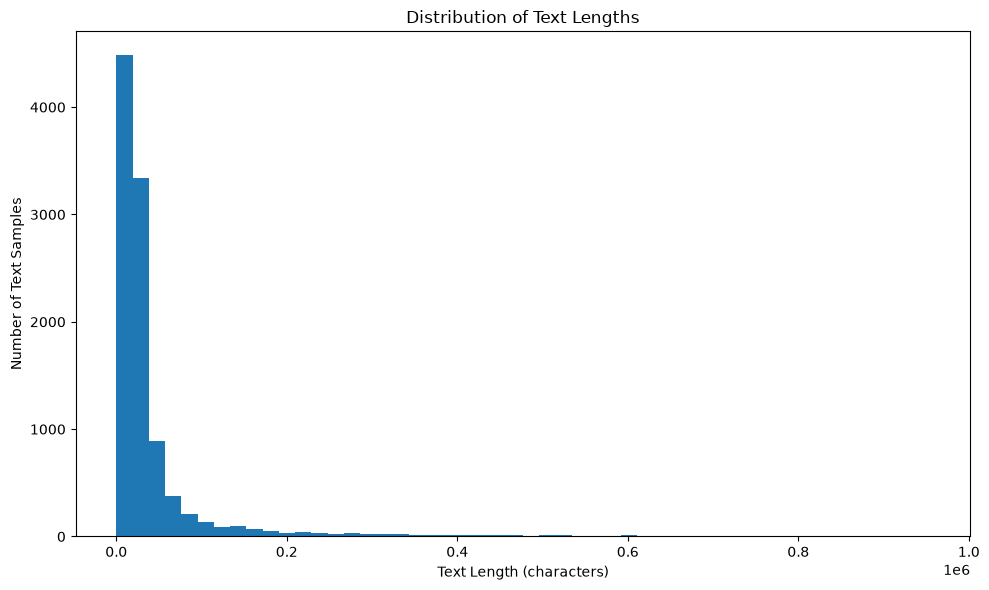

In [18]:
text_length_pd = (
    text_length_df
    .select("text_length")
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.hist(text_length_pd["text_length"], bins=50)
plt.xlabel("Text Length (characters)")
plt.ylabel("Number of Text Samples")
plt.title("Distribution of Text Lengths")
plt.tight_layout()
plt.show()

## Analysis of Outliers

The interquartile range (IQR) is used to analyze text length outliers. This aids in locating texts that are abnormally long or short, which could have an impact on model training and preprocessing. Instead of automatically eliminating legitimate literary pieces, the analysis will guide the choice of a suitable sequence length.

In [19]:
q1 = text_length_pd["text_length"].quantile(0.25)
q3 = text_length_pd["text_length"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outliers = text_length_pd[
    (text_length_pd["text_length"] < lower_bound) |
    (text_length_pd["text_length"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 13054.5
Q3: 35727.0
IQR: 22672.5
Lower bound: -20954.25
Upper bound: 69735.75
Number of outliers: 1202


## Outlier Results

1,202 observations with text lengths longer than the upper limit of around 69,736 characters were found by the IQR analysis. Since these observations reflect legitimate literary texts rather than data entry mistakes, they are not automatically eliminated. In order to handle larger texts reliably, a predetermined maximum sequence length will be applied during LSTM preprocessing.

## Balancing Datasets

The original dataset contains substantial differences in the number of samples per author. To reduce class bias, authors with at least 100 observations were selected and 100 text samples were randomly sampled from each author. This produced a balanced dataset of 2,200 observations across 22 authors, with equal representation of each class.

In [23]:
from pyspark.sql.functions import rand

In [24]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Select authors with at least 100 records
eligible_authors = (
    author_counts
    .filter(col("count") >= 100)
    .select("author")
)

balanced_df = (
    spark_df
    .join(eligible_authors, on="author", how="inner")
)

# Randomly select 100 records per author
window = Window.partitionBy("author").orderBy(rand())

balanced_df = (
    balanced_df
    .withColumn("row_num", row_number().over(window))
    .filter(col("row_num") <= 100)
    .drop("row_num")
)

print("Balanced records:", balanced_df.count())

balanced_df.groupBy("author").count().orderBy("author").show(30, truncate=False)

Balanced records: 2200
+----------------------+-----+
|author                |count|
+----------------------+-----+
|Alexandre Dumas       |100  |
|Andrew Lang           |100  |
|Charles Dickens       |100  |
|Edith Wharton         |100  |
|Elizabeth C. Gaskell  |100  |
|George Borrow         |100  |
|George Eliot          |100  |
|H. G. Wells           |100  |
|Hans C. Andersen      |100  |
|Henry James           |100  |
|Jack London           |100  |
|Jane Austen           |100  |
|Joseph Conrad         |100  |
|Jules Verne           |100  |
|Leo Tolstoy           |100  |
|Mark Twain            |100  |
|Miguel De Cervantes   |100  |
|Robert Louis Stevenson|100  |
|Sir Arthur Conan Doyle|100  |
|Thomas Hardy          |100  |
|Walter Scott          |100  |
|Wilkie Collins        |100  |
+----------------------+-----+



## Quality Check of the Balanced Dataset

Before preparing the model, the balanced dataset is examined once again for missing values. This guaranties that no incomplete observations were introduced throughout the sampling and balancing procedure.

In [26]:
balanced_df.select([
    spark_sum(
        when(
            col(c).isNull() | (trim(col(c).cast("string")) == ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in balanced_df.columns
]).show()

+------+-------+-------+--------+----+
|author|text_id|book_id|bookname|text|
+------+-------+-------+--------+----+
|     0|      0|      0|       0|   0|
+------+-------+-------+--------+----+



## Preprocessing Text

In order to prepare the balanced text dataset for LSTM modeling, the literary text is transformed into numerical sequences and the author labels are converted into numerical classes. Padding will guaranty that every sequence has a uniform length, and tokenization will be carried out using the training data to minimize data leakage.

In [27]:
balanced_pd = balanced_df.toPandas()

print("Records:", len(balanced_pd))
print("Authors:", balanced_pd["author"].nunique())
balanced_pd.head()

C:\Users\luten\anaconda3\envs\lstm_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Records: 2200
Authors: 22


,author,text_id,book_id,bookname,text
0,Elizabeth C. Gaskell,72,405,North And South,"<HTML>\n\n<HEAD>\n\n <META HTTP-EQUIV=""Conte..."
1,Elizabeth C. Gaskell,72,405,North And South,"<HTML>\n\n<HEAD>\n\n <META HTTP-EQUIV=""Conte..."
2,Elizabeth C. Gaskell,72,1081,Wives And Daughters,"<HTML>\n\n<HEAD>\n\n <META HTTP-EQUIV=""Conte..."
3,Elizabeth C. Gaskell,72,648,Sylvia's Lovers,"<HTML>\n\n<HEAD>\n\n <META HTTP-EQUIV=""Conte..."
4,Elizabeth C. Gaskell,72,1081,Wives And Daughters,"<HTML>\n\n<HEAD>\n\n <META HTTP-EQUIV=""Conte..."


## Cleaning Text

HTML formatting tags from the source files are present in the text. Since these tags don't provide any significant linguistic information, they are eliminated prior to tokenization. Additionally, unnecessary whitespace is normalized and text is changed to lowercase.

In [28]:
import re

def clean_text(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

balanced_pd["clean_text"] = balanced_pd["text"].apply(clean_text)

print(balanced_pd[["author", "clean_text"]].head())

                   author                                         clean_text
0  Elizabeth C. Gaskell    chapter11 chapter xi first impressions &nbsp; ...
1  Elizabeth C. Gaskell    chapter13 chapter xiii a soft breeze in a sult...
2  Elizabeth C. Gaskell    chapter29 chapter xxix bush-fighting during al...
3  Elizabeth C. Gaskell    chapter27 &nbsp; chapter xxvii gloomy days phi...
4  Elizabeth C. Gaskell    chapter52 chapter lii squire hamley's sorrow i...


## Cleaning HTML Entities

After the HTML tags are removed, some HTML entities, including `&nbsp;` are still present. To provide the tokenizer with clearer literary content, these formatting artifacts are eliminated.

In [29]:
import html

balanced_pd["clean_text"] = (
    balanced_pd["clean_text"]
    .apply(html.unescape)
)

balanced_pd["clean_text"] = (
    balanced_pd["clean_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(balanced_pd[["author", "clean_text"]].head())

                   author                                         clean_text
0  Elizabeth C. Gaskell    chapter11 chapter xi first impressions 'there'...
1  Elizabeth C. Gaskell    chapter13 chapter xiii a soft breeze in a sult...
2  Elizabeth C. Gaskell    chapter29 chapter xxix bush-fighting during al...
3  Elizabeth C. Gaskell    chapter27 chapter xxvii gloomy days philip had...
4  Elizabeth C. Gaskell    chapter52 chapter lii squire hamley's sorrow i...


## Train and Test Split

An 80:20 split is used to separate the cleaned dataset into training and testing sets. To maintain the equal representation of each of the 22 writers in both sets, stratification is used. To ensure an objective assessment of the finished model, the test set is kept apart from model training.

In [30]:
from sklearn.model_selection import train_test_split

X = balanced_pd["clean_text"]
y = balanced_pd["author"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training authors:", y_train.nunique())
print("Testing authors:", y_test.nunique())

Training samples: 1760
Testing samples: 440
Training authors: 22
Testing authors: 22


## Encoding Labels

Before the neural network can use the author names, which are category labels, they must be transformed into numerical values. A distinct integer label is given to each of the 22 authors.

In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Number of classes:", len(label_encoder.classes_))
print("Classes:")
print(label_encoder.classes_)

Number of classes: 22
Classes:
['Alexandre Dumas' 'Andrew Lang' 'Charles Dickens' 'Edith Wharton  '
 'Elizabeth C. Gaskell  ' 'George Borrow' 'George Eliot' 'H. G. Wells  '
 'Hans C. Andersen' 'Henry James' 'Jack London' 'Jane Austen'
 'Joseph Conrad  ' 'Jules Verne' 'Leo Tolstoy  ' 'Mark Twain  '
 'Miguel De Cervantes ' 'Robert Louis Stevenson' 'Sir Arthur Conan Doyle'
 'Thomas Hardy' 'Walter Scott' 'Wilkie Collins  ']


##  Text Tokenisation

Keras `TextVectorization` is used to transform the cleaned text into numerical sequences. To avoid information from the test set affecting the model, the vocabulary is exclusively learned from the training data. Computational complexity is managed by setting a maximum vocabulary size.

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 500

vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

vectorizer.adapt(X_train)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 20000


## Sequence Conversion

Fixed-length number sequences are created from the tokenized text. There are a maximum of 500 tokens in each sequence. To create a uniform input shape for the LSTM model, longer letters are trimmed and shorter texts are padded.

In [34]:
X_train_seq = vectorizer(X_train)
X_test_seq = vectorizer(X_test)

print("Training shape:", X_train_seq.shape)
print("Testing shape:", X_test_seq.shape)

Training shape: (1760, 500)
Testing shape: (440, 500)


## Initial LSTM Model

To categorize the text into 22 author classes, an LSTM neural network is created. While the LSTM layer discovers sequential patterns in the text, an embedding layer transforms the tokenized words into dense numerical representations. A softmax output layer is used for multi-class classification when dropout is incorporated to lessen overfitting.

In [38]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 500, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 22)                  │           1,430 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,614,998 (9.98 MB)

 Trainable params: 2,614,998 (9.98 MB)

 Non-trainable params: 0 (0.00 B)

##  LSTM Model Training

The training dataset is used to train the first LSTM model. Early stopping is utilized to restrict overfitting and minimize needless training, while a validation set is used to track generalization during training. The model is trained using a batch size of 32 for a maximum of 10 epochs.

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 396ms/step - accuracy: 0.0497 - loss: 3.0919 - val_accuracy: 0.0341 - val_loss: 3.0941
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 478ms/step - accuracy: 0.1009 - loss: 3.0735 - val_accuracy: 0.0568 - val_loss: 3.0906
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 435ms/step - accuracy: 0.1541 - loss: 3.0178 - val_accuracy: 0.0597 - val_loss: 3.0797
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 425ms/step - accuracy: 0.1982 - loss: 2.7147 - val_accuracy: 0.0909 - val_loss: 3.0225
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 430ms/step - accuracy: 0.3189 - loss: 2.1731 - val_accuracy: 0.0966 - val_loss: 3.2635
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 426ms/step - accuracy: 0.5014 - loss: 1.5804 - val_accuracy: 0.1278 - val_loss: 3.4688


## Initial Training Results

By epoch 6, the original LSTM model's training accuracy has increased to 50.14%. However, validation loss worsened after the fourth epoch, and validation accuracy stayed much lower at 12.78%. These findings show that the model is not effectively generalizing to new text and is starting to overfit the training set. Because it avoids needless training and restores the model weights from the best validation performance, early halting is therefore suitable. Before changing the model's parameters, the outcomes will be further assessed using categorization metrics.

##  Model Evaluation

The unseen test dataset is used to assess the trained LSTM model. The 22 author classes' classification performance is evaluated using accuracy, precision, recall, and F1-score. Additionally, authors who are regularly misclassified are identified using a confusion matrix.

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Generate predictions
y_pred_prob = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded, y_pred, average="weighted", zero_division=0
)
recall = recall_score(
    y_test_encoded, y_pred, average="weighted", zero_division=0
)
f1 = f1_score(
    y_test_encoded, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step
Accuracy:  0.0841
Precision: 0.0511
Recall:    0.0841
F1-score:  0.0543


In [41]:
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

       Alexandre Dumas       0.00      0.00      0.00        20
           Andrew Lang       0.00      0.00      0.00        20
       Charles Dickens       0.06      0.05      0.05        20
       Edith Wharton         0.00      0.00      0.00        20
Elizabeth C. Gaskell         0.00      0.00      0.00        20
         George Borrow       0.00      0.00      0.00        20
          George Eliot       0.00      0.00      0.00        20
         H. G. Wells         0.00      0.00      0.00        20
      Hans C. Andersen       0.12      0.05      0.07        20
           Henry James       0.00      0.00      0.00        20
           Jack London       0.00      0.00      0.00        20
           Jane Austen       0.15      0.35      0.21        20
       Joseph Conrad         0.12      0.10      0.11        20
           Jules Verne       0.11      0.20      0.14        20
         Leo Tolstoy         0.08      

## Initial Evaluation Findings

On the test dataset, the original LSTM obtained an accuracy of 8%, with weighted precision, recall, and F1-score of roughly 5%, 8%, and 5%, respectively.

Weak generalization to unseen text is indicated by the results. While some authors were incorrectly identified, others, including Jane Austen and Thomas Hardy, had stronger recall than other classes. This implies that learning sufficiently unique patterns across the 22 author classes was a challenge for the original model.

The poor test performance suggests overfitting when combined with the training outcomes. In order to improve generalization, model parameters will be changed and the LSTM will be retrained.

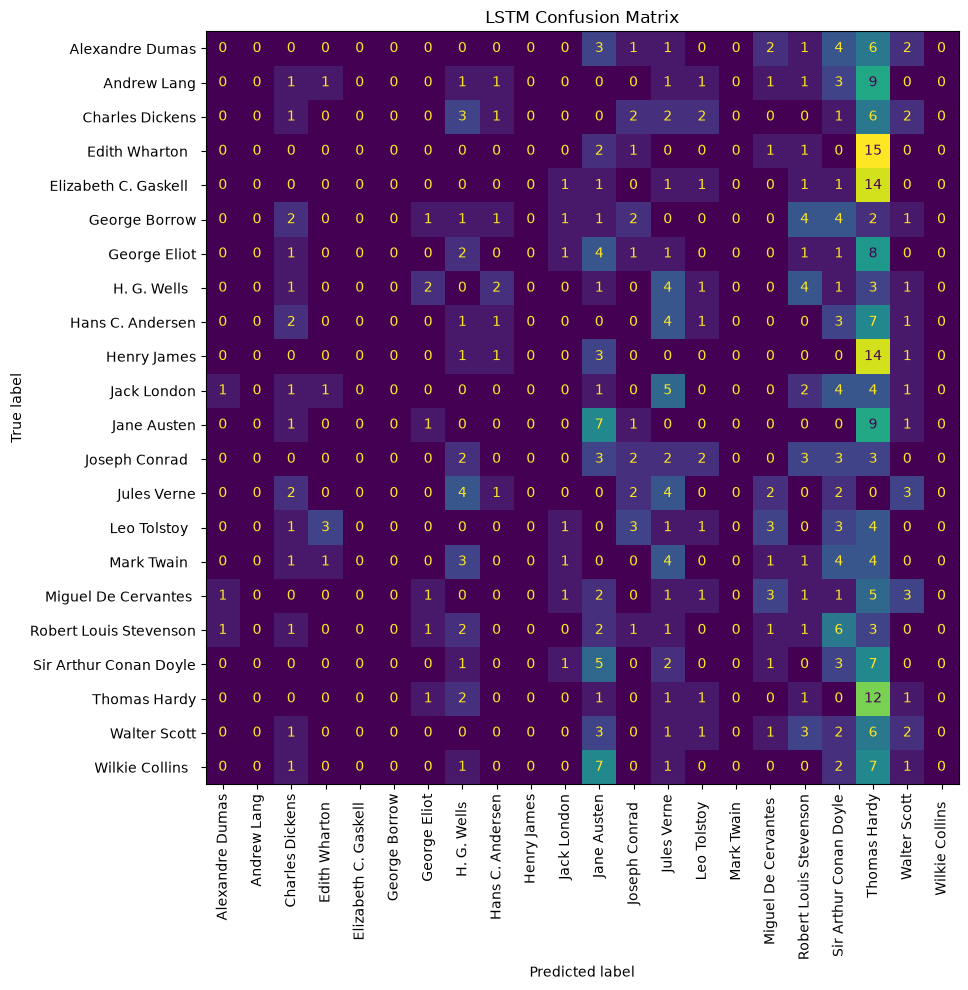

In [42]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=90,
    colorbar=False
)

plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

## Model Improvement

The original model exhibited significant overfitting, with test and validation performance staying poor while training accuracy increased. The model will be retrained with a smaller LSTM layer and more dropout in order to improve generalization.

The updated model raises dropout from 0.3 to 0.5 and use 32 LSTM units rather than 64. By using stronger regularization and reducing model complexity, these modifications may improve the model's ability to generalize to previously encountered text.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

improved_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),
    
    LSTM(32),
    Dropout(0.5),
    
    Dense(32, activation="relu"),
    Dropout(0.5),
    
    Dense(num_classes, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 500, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 22)                  │             726 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,582,390 (9.85 MB)

 Trainable params: 2,582,390 (9.85 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
improved_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    X_train_seq,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[improved_early_stopping],
    verbose=1
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.0405 - loss: 3.0919 - val_accuracy: 0.0341 - val_loss: 3.0915
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 267ms/step - accuracy: 0.0675 - loss: 3.0824 - val_accuracy: 0.0455 - val_loss: 3.0916
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 303ms/step - accuracy: 0.0724 - loss: 3.0647 - val_accuracy: 0.0540 - val_loss: 3.0856
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step - accuracy: 0.0888 - loss: 3.0230 - val_accuracy: 0.0682 - val_loss: 3.0585
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 324ms/step - accuracy: 0.1108 - loss: 2.9011 - val_accuracy: 0.0625 - val_loss: 3.0623
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 335ms/step - accuracy: 0.1605 - loss: 2.7166 - val_accuracy: 0.0682 - val_loss: 3.0798


## Revised Model Configuration

Although overfitting was lessened by the first improved model, validation accuracy was also decreased. This implies that it was overly restrictive to limit the LSTM capacity to 32 units.

A second setup will increase dropout from 0.3 to 0.4 while keeping 64 LSTM units. In order to promote generalization, more regularization is applied while maintaining a higher learning capacity.

In [45]:
improved_model_2 = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),
    
    LSTM(64),
    Dropout(0.4),
    
    Dense(64, activation="relu"),
    Dropout(0.4),
    
    Dense(num_classes, activation="softmax")
])

improved_model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 500, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 22)                  │           1,430 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,614,998 (9.98 MB)

 Trainable params: 2,614,998 (9.98 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
improved_history_2 = improved_model_2.fit(
    X_train_seq,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )],
    verbose=1
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.0419 - loss: 3.0928 - val_accuracy: 0.0625 - val_loss: 3.0902
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 429ms/step - accuracy: 0.0703 - loss: 3.0873 - val_accuracy: 0.0455 - val_loss: 3.0904
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 455ms/step - accuracy: 0.0902 - loss: 3.0699 - val_accuracy: 0.0625 - val_loss: 3.0808
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 464ms/step - accuracy: 0.1349 - loss: 3.0034 - val_accuracy: 0.0540 - val_loss: 3.0155
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 500ms/step - accuracy: 0.1477 - loss: 2.7924 - val_accuracy: 0.0909 - val_loss: 2.9691
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 512ms/step - accuracy: 0.2244 - loss: 2.4686 - val_accuracy: 0.1023 - val_loss: 2.9182
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 533ms/step - accuracy: 0.3636 - loss: 2.0217 - val_accuracy: 0.1193 - val_loss: 3.0392
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 492ms/step - accuracy: 0.4787 - loss: 1.6226 - val_accu

## Model Improvement Results

The second model configuration produced better validation performance than the first revised model. Validation accuracy increased to 14.49%, compared with 6.82% for the previous configuration.

However, the model still showed signs of overfitting. Training accuracy increased to 47.87%, while validation accuracy remained considerably lower and validation loss increased after epoch 6.

The second configuration therefore provides the best validation performance so far, although its generalisation remains limited. The model will now be evaluated on the unseen test dataset and compared with the initial model.

In [47]:
y_pred_prob_2 = improved_model_2.predict(X_test_seq)
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

accuracy_2 = accuracy_score(y_test_encoded, y_pred_2)
precision_2 = precision_score(
    y_test_encoded, y_pred_2,
    average="weighted",
    zero_division=0
)
recall_2 = recall_score(
    y_test_encoded, y_pred_2,
    average="weighted",
    zero_division=0
)
f1_2 = f1_score(
    y_test_encoded, y_pred_2,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:  {accuracy_2:.4f}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall:    {recall_2:.4f}")
print(f"F1-score:  {f1_2:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step
Accuracy: 0.1182
Precision: 0.1760
Recall:    0.1182
F1-score:  0.0744


In [48]:
print(f"Accuracy:  {accuracy_2:.4f}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall:    {recall_2:.4f}")
print(f"F1-score:  {f1_2:.4f}")

Accuracy:  0.1182
Precision: 0.1760
Recall:    0.1182
F1-score:  0.0744


##  Model Comparison

The test accuracy of the enhanced LSTM model was 11.82%, while that of the original model was 8.00%. Additionally, precision rose from roughly 5.00% to 17.60%. The F1-score rose to 7.44% and recall rose to 11.82%.

Even if the enhanced model performed better on tests, the outcomes are still not very good. Another sign that overfitting is still a problem is the difference between training and validation performance. However, because the second configuration outperformed the first on untested data, it is chosen as the final model.

In [49]:
print(
    classification_report(
        y_test_encoded,
        y_pred_2,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

       Alexandre Dumas       1.00      0.05      0.10        20
           Andrew Lang       0.12      0.05      0.07        20
       Charles Dickens       0.00      0.00      0.00        20
       Edith Wharton         0.14      0.10      0.12        20
Elizabeth C. Gaskell         0.06      0.05      0.05        20
         George Borrow       0.00      0.00      0.00        20
          George Eliot       0.00      0.00      0.00        20
         H. G. Wells         0.00      0.00      0.00        20
      Hans C. Andersen       1.00      0.05      0.10        20
           Henry James       0.06      0.10      0.08        20
           Jack London       0.00      0.00      0.00        20
           Jane Austen       0.16      0.55      0.25        20
       Joseph Conrad         0.00      0.00      0.00        20
           Jules Verne       0.20      0.45      0.28        20
         Leo Tolstoy         0.11      

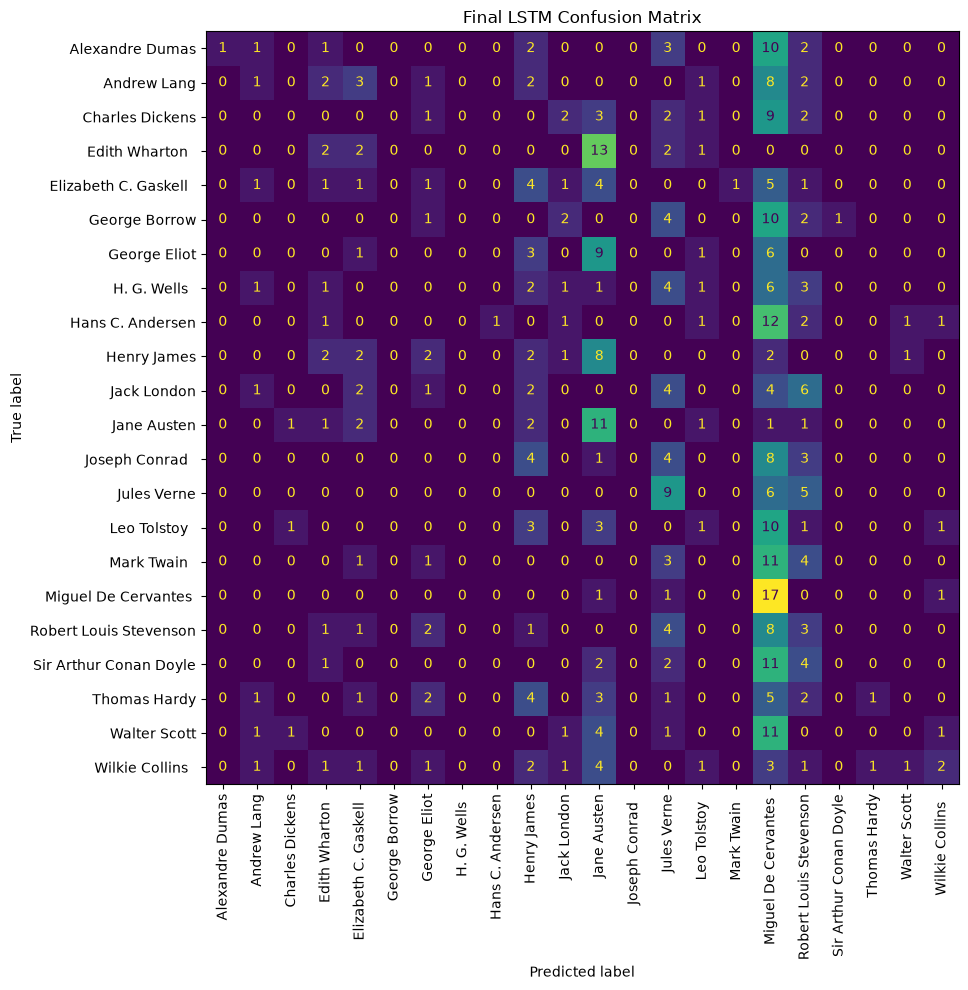

In [50]:
cm_2 = confusion_matrix(y_test_encoded, y_pred_2)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_2,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=90,
    colorbar=False
)

plt.title("Final LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

## Final Classification Results

The resulting LSTM obtained an F1-score of 7.44%, recall of 11.82%, weighted precision of 17.60%, and test accuracy of 11.82%.

The authors' performances differed greatly from one another. At 85%, Miguel De Cervantes had the highest recall, followed by Jane Austen at 55% and Jules Verne at 45%. On the other hand, a number of authors had zero recollection, which suggests that their texts were often incorrectly categorized.

The findings show that while the model picked up some author-specific characteristics, it had trouble making consistent generalizations across all 22 classes. The overfitting seen during training is likewise in line with this.

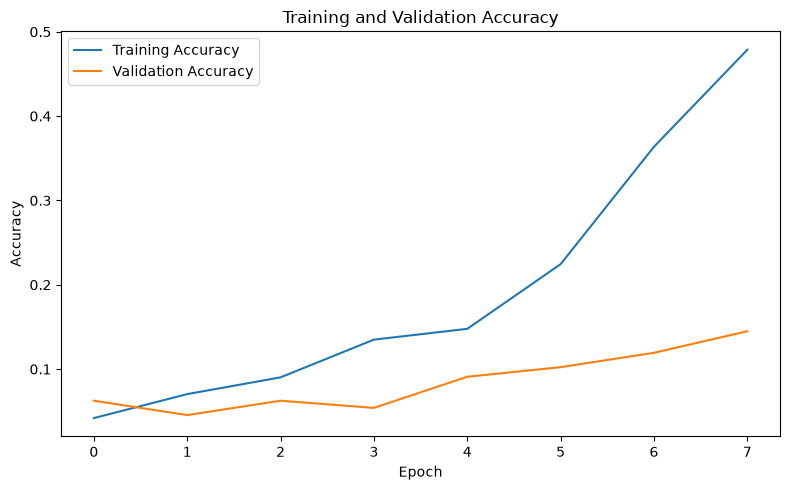

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history_2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    improved_history_2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

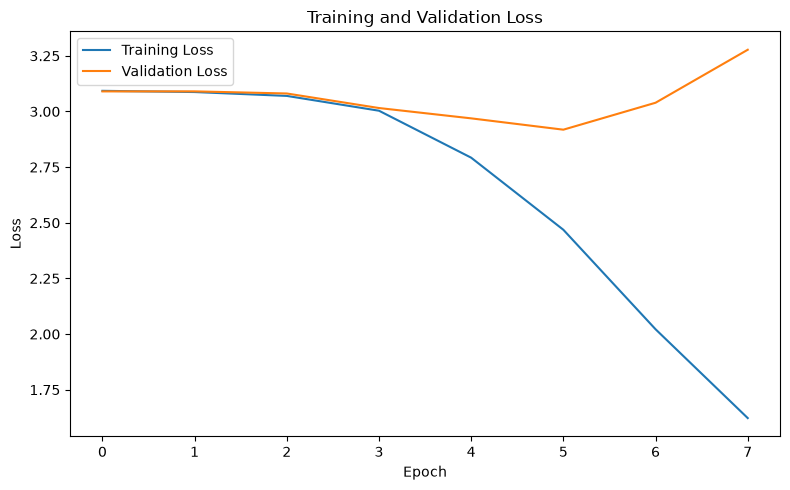

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history_2.history["loss"],
    label="Training Loss"
)

plt.plot(
    improved_history_2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Final Model Summary

The final LSTM model has an embedding dimension of 128, a maximum sequence length of 500 tokens, and a vocabulary size of 20,000 tokens. The model had a 64-unit LSTM layer, a 22-class softmax output layer, a 64-unit dense layer, and dropout layers with a rate of 0.4.

Sparse categorical cross-entropy loss and the Adam optimizer were used to train the model. To reduce overfitting and recover the optimal validation weights, early halting was employed.